<a href="https://colab.research.google.com/github/yuhui-0611/SEED/blob/main/%ED%8F%90%EC%97%85%EB%A5%A0_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt-get -qq install fonts-nanum

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install pandas matplotlib seaborn openpyxl

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Mounted at /content/drive


In [ ]:
import numpy as np

In [ ]:
file_path = '/content/drive/MyDrive/2025/seed/전체_통합.xlsx'
df = pd.read_excel(file_path)

df[['연도', '분기']] = df['연도_분기'].str.split('-', expand=True)
df['분기'] = df['분기'].str.replace('Q', '').astype(int)
df['연도'] = df['연도'].astype(int)

In [ ]:
print(df.head())

     행정구역    연도_분기   전체점포수  프랜차이즈 점포수  일반 점포수  개업률  폐업률  1년 생존율  5년 생존율  \
0  서울시 전체  2015-Q1  571434      38561  532873  3.1  3.9    75.0    36.8   
1     종로구  2015-Q1   25276       1306   23970  2.5  3.4    80.0    42.2   
2      중구  2015-Q1   43310       1642   41668  2.7  3.7    81.2    44.1   
3     용산구  2015-Q1   18912        969   17943  2.9  3.6    78.8    41.7   
4     성동구  2015-Q1   15655       1030   14625  3.2  3.7    77.8    40.2   

      log인구   환산임대료  10년영업기간  30년영업기간   실업률  소비자심리지수(평균)  소득분위  1년 생존율 차분  \
0  7.015740   96760      3.6      5.3  4.07   102.966667     7        NaN   
1  5.218115  151285      3.8      6.1  4.07   102.966667     7        NaN   
2  5.133740  191889      4.0      6.0  4.07   102.966667     7        NaN   
3  5.397945   95330      3.8      5.5  4.07   102.966667     8        NaN   
4  5.482555   76623      3.7      5.6  4.07   102.966667     7        NaN   

   5년 생존율 차분    연도  분기  
0        NaN  2015   1  
1        NaN  2015   1  
2        Na

# 데이터 기본 통계
- 변수별 평균, 표준편차, 최소값, 최대값 확인

In [ ]:
from IPython.display import display, HTML

display(HTML(df.describe().round(2).to_html()))


,전체점포수,프랜차이즈 점포수,일반 점포수,개업률,폐업률,1년 생존율,5년 생존율,log인구,환산임대료,10년영업기간,30년영업기간,실업률,소비자심리지수(평균),소득분위,1년 생존율 차분,5년 생존율 차분,연도,분기
count,1040.00,1040.00,1040.00,1040.00,1040.00,1040.00,1040.00,1040.00,1040.00,1040.00,1040.00,1040.00,1040.00,1040.00,1014.00,1014.00,1040.00,1040.00
mean,46730.37,3685.18,43045.19,3.29,2.99,77.13,42.21,5.63,111805.72,3.31,5.31,3.48,99.80,7.09,0.15,0.28,2019.50,2.50
std,112871.69,8961.76,103952.12,0.92,0.60,3.56,6.24,0.32,36433.27,0.19,0.33,0.65,6.79,0.82,0.95,1.71,2.87,1.12
min,11700.00,828.00,10706.00,1.20,1.20,69.00,29.10,5.12,61997.00,2.80,4.80,2.17,78.00,6.00,-3.80,-4.10,2015.00,1.00
25%,18167.75,1431.00,16519.00,2.80,2.60,74.40,36.55,5.51,88468.25,3.20,5.10,2.99,97.48,7.00,0.00,0.00,2017.00,1.75
50%,21148.00,1752.50,19192.00,3.30,2.95,77.20,43.10,5.61,103124.50,3.30,5.25,3.46,100.75,7.00,0.00,0.00,2019.50,2.50
75%,28121.00,2259.50,25675.50,3.80,3.40,80.00,46.90,5.69,123142.00,3.40,5.50,3.97,103.32,7.00,0.00,0.00,2022.00,3.25
max,663473.00,55536.00,608156.00,23.00,4.60,86.60,56.60,7.02,292292.00,4.00,6.50,4.97,112.00,9.00,6.20,15.50,2024.00,4.00


# 변수 분포


1. 폐업률

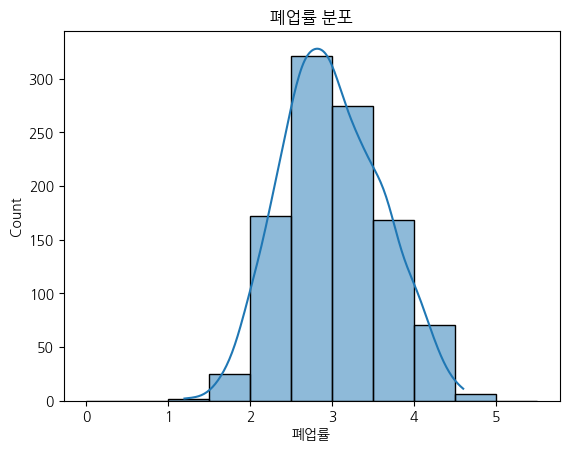

In [ ]:
sns.histplot(df['폐업률'], bins=np.arange(0, 6, 0.5), kde=True)
plt.title('폐업률 분포')
plt.show()

평균 약 3%, 대부분 2%~4% 분포.

좌우 대칭적이고 정규분포에 가까운 형태.

2. 개업률

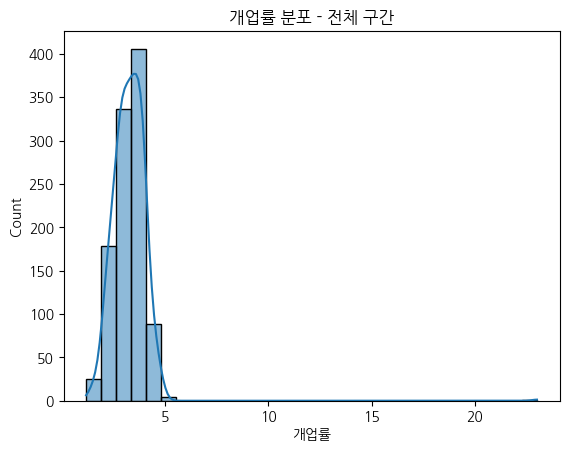

In [ ]:
#이상치 포함
sns.histplot(df['개업률'], bins=30, kde=True)
plt.title('개업률 분포 - 전체 구간')
plt.show()

평균 약 3.3%, 주로 1%~5% 구간에 몰림.

우측 왜도 심함 (10% 이상 극단치 존재).

*2023년 q3 종로구 23 오류*

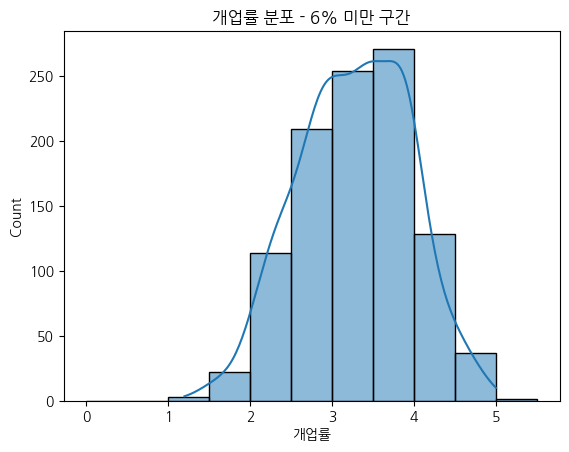

In [ ]:
sns.histplot(df[df['개업률'] < 6]['개업률'], bins=np.arange(0, 6, 0.5), kde=True)
plt.title('개업률 분포 - 6% 미만 구간')
plt.show()

3. 소득분위

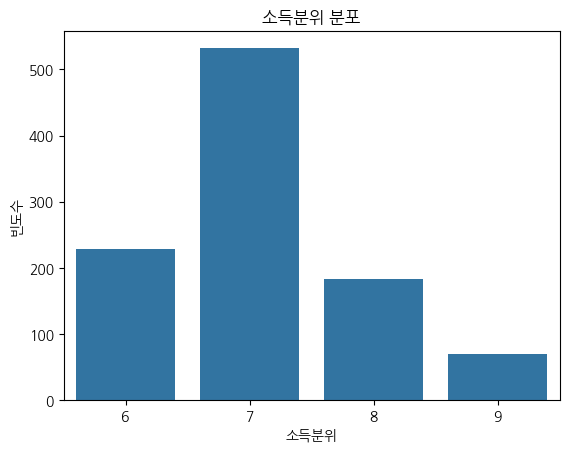

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 소득분위별 빈도수 계산
income_counts = df['소득분위'].value_counts().sort_index()

# 바 플롯 시각화
sns.barplot(x=income_counts.index, y=income_counts.values)
plt.xlabel('소득분위')
plt.ylabel('빈도수')
plt.title('소득분위 분포')
plt.show()

4. 환산임대료

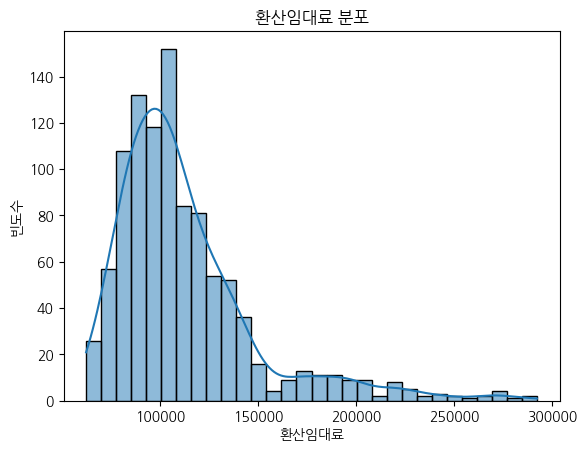

In [ ]:
sns.histplot(df['환산임대료'], bins=30, kde=True)
plt.title('환산임대료 분포')
plt.xlabel('환산임대료')
plt.ylabel('빈도수')
plt.show()



*   우측 왜도 분포


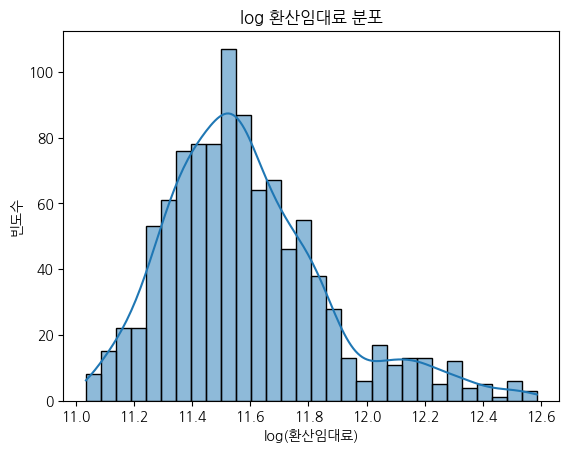

In [ ]:
#log_환산임대료
df['log_환산임대료'] = np.log1p(df['환산임대료'])

sns.histplot(df['log_환산임대료'], bins=30, kde=True)
plt.title('log 환산임대료 분포')
plt.xlabel('log(환산임대료)')
plt.ylabel('빈도수')
plt.show()



*   우측 꼬리 쏠림 완화
*  변수의 분포를 정규에 가깝게 만들고 해석의 직관성을 높이기 위해 로그 변환 적용



5. 10년, 30년 영업기간

- 10년영업기간은 최근 10년간 개·폐업한 점포 대상 -> 단기적 생존력 지표

- 30년영업기간은 1990년부터 현재까지 개·폐업한 점포 대상 -> 장기적 상권 안정성 지표

관찰 기간과 설명하고자 하는 경제적 특성이 다름. 따로 사용하는게 나아보임.

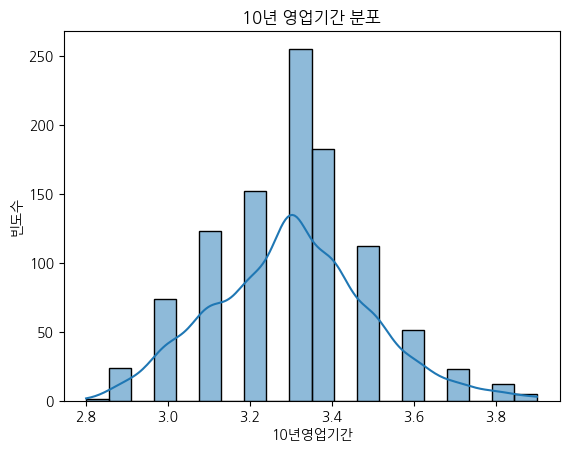

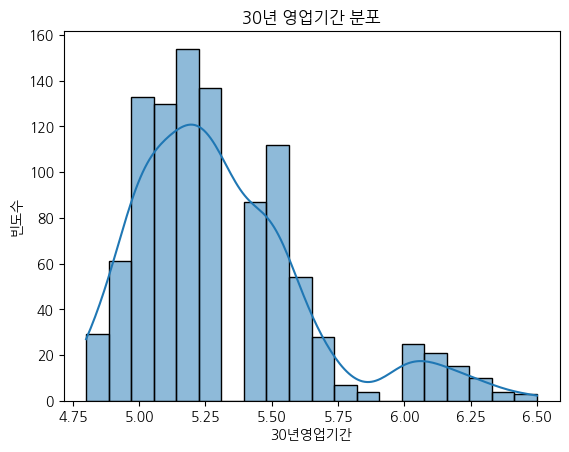

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 10년 영업기간 분포
sns.histplot(df['10년영업기간'], bins=20, kde=True)
plt.title('10년 영업기간 분포')
plt.xlabel('10년영업기간')
plt.ylabel('빈도수')
plt.show()

# 30년 영업기간 분포
sns.histplot(df['30년영업기간'], bins=20, kde=True)
plt.title('30년 영업기간 분포')
plt.xlabel('30년영업기간')
plt.ylabel('빈도수')
기ㄴ: plt.show()



*   영업기간: 정규분포에 가까움 -> 변환 필요 없음.


# 변수 간 관계 시각화

1. 소비심리지수와 폐업률

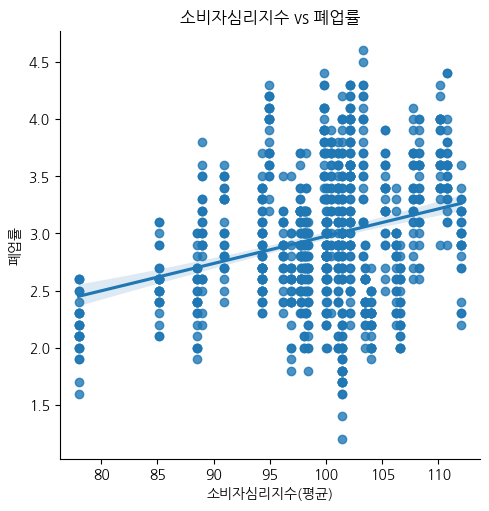

소비자심리지수와 폐업률 간 상관계수: 0.2792


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 산점도 + 회귀선
sns.lmplot(data=df, x='소비자심리지수(평균)', y='폐업률')
plt.title('소비자심리지수 vs 폐업률')
plt.show()

# 상관계수 계산
corr = df[['소비자심리지수(평균)', '폐업률']].corr().iloc[0, 1]
print(f"소비자심리지수와 폐업률 간 상관계수: {corr:.4f}")

약한 양의 상관 관계 보임.

소비심리지수는 선행지표인데 폐업은 시차 두고 발생함.

2. 소득분위와 폐업률

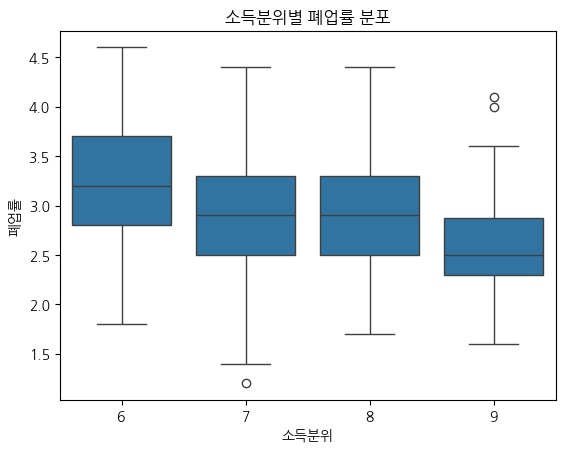

In [ ]:
sns.boxplot(x='소득분위', y='폐업률', data=df)
plt.title('소득분위별 폐업률 분포')
plt.show()

소득분위가 높아질수록 중앙값(폐업률)이 감소하는 경향

*   특히 9분위에서는 폐업률 중앙값이 가장 낮고, 전체 분포도 안정적.

*   저소득권(6분위)은 폐업률 분산도 크고, 중앙값도 가장 높음.

3. 개업률과 폐업률

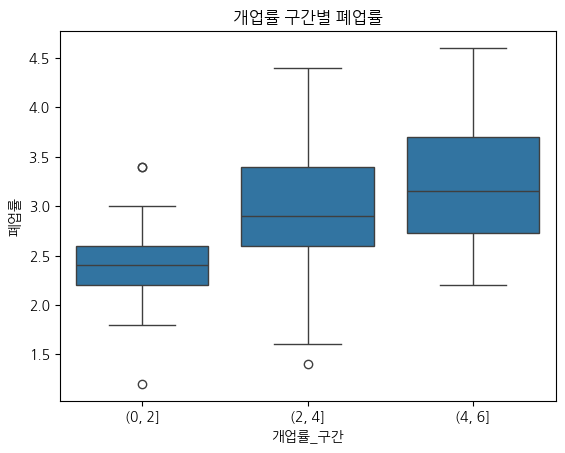

In [ ]:
#

df['개업률_구간'] = pd.cut(df['개업률'], bins=[0, 2, 4, 6])
sns.boxplot(x='개업률_구간', y='폐업률', data=df)
plt.title('개업률 구간별 폐업률')
plt.show()

개업률이 높을수록 폐업률 상승

4. 환산임대료와 소득분위

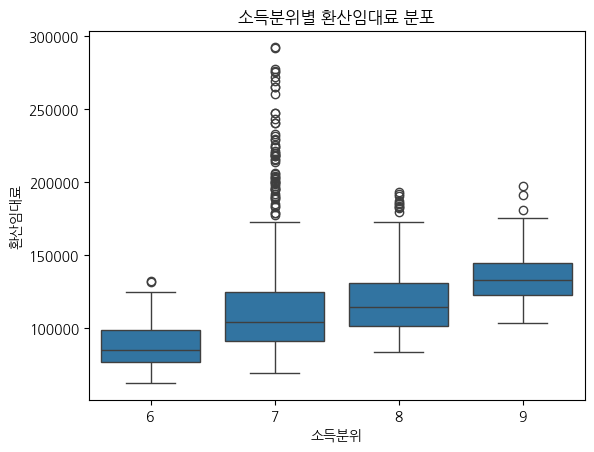

소득분위와 환산임대료 간 상관계수: 0.3450


In [ ]:
sns.boxplot(x='소득분위', y='환산임대료', data=df)
plt.title('소득분위별 환산임대료 분포')
plt.show()

# 상관계수 (Pearson)
corr = df[['소득분위', '환산임대료']].corr().iloc[0, 1]
print(f"소득분위와 환산임대료 간 상관계수: {corr:.4f}")





*   약한 양의 상관(같이 사용해도 문제 없음)


고소득권 지역(8~9 분위)의 경우, 임대료가 높긴 하지만 분포가 비교적 안정적.

7분위에서 상권별 임대료 격차가 가장 큼 → 중상위 소득권에서 상권 양극화 가능성.

# 다중공선성 확인


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import pandas as pd

In [ ]:
X = df[['1년 생존율', '5년 생존율', '실업률', '소비자심리지수(평균)',
        'log인구', '환산임대료', '10년영업기간', '30년영업기간',
        '전체점포수', '프랜차이즈 점포수', '일반 점포수',
        '개업률', '폐업률']]

X = sm.add_constant(X)

vif_df = pd.DataFrame()
vif_df["변수명"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_df.round(2))


            변수명      VIF
0         const  7006.01
1        1년 생존율     8.09
2        5년 생존율     9.75
3           실업률     1.40
4   소비자심리지수(평균)     1.23
5         log인구     9.44
6         환산임대료     2.62
7       10년영업기간     2.20
8       30년영업기간     3.27
9         전체점포수      inf
10    프랜차이즈 점포수      inf
11       일반 점포수      inf
12          개업률     1.27
13          폐업률     2.58


/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


*   전체 점포수 = 프랜차이즈 점포수 + 일반 점포수 (VIF 무한대) -> 비율 변수로

*   1년 생존율과 5년 생존율 -> 차분 변수로 대체 (변화량에 대한 정보만 남기기)

*   log 인구 (점포수 규모와 관련?)



In [ ]:
df['프랜차이즈_비율'] = df['프랜차이즈 점포수'] / df['전체점포수']

In [ ]:
# NaN 있는 행 제거
vif_data = df[['1년 생존율 차분', '5년 생존율 차분', '실업률', '소비자심리지수(평균)',
                'log인구', '환산임대료', '10년영업기간', '30년영업기간',
                '프랜차이즈_비율', '개업률', '폐업률']].dropna()

# 상수항 추가
X = sm.add_constant(vif_data)

# VIF 재계산
vif_df = pd.DataFrame()
vif_df["변수명"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_df.round(2))


            변수명      VIF
0         const  2246.56
1     1년 생존율 차분     2.01
2     5년 생존율 차분     2.00
3           실업률     1.37
4   소비자심리지수(평균)     1.28
5         log인구     1.14
6         환산임대료     1.96
7       10년영업기간     2.01
8       30년영업기간     3.20
9      프랜차이즈_비율     1.96
10          개업률     1.28
11          폐업률     1.72




---



소득분위 포함

In [ ]:
# NaN 있는 행 제거
vif_data = df[['1년 생존율 차분', '5년 생존율 차분', '실업률', '소비자심리지수(평균)',
                'log인구', '환산임대료', '10년영업기간', '30년영업기간',
                '프랜차이즈_비율', '개업률', '소득분위', '폐업률']].dropna()

# 상수항 추가
X = sm.add_constant(vif_data)

# VIF 재계산
vif_df = pd.DataFrame()
vif_df["변수명"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_df.round(2))


            변수명      VIF
0         const  2332.97
1     1년 생존율 차분     2.01
2     5년 생존율 차분     2.00
3           실업률     1.38
4   소비자심리지수(평균)     1.29
5         log인구     1.17
6         환산임대료     2.12
7       10년영업기간     2.01
8       30년영업기간     3.29
9      프랜차이즈_비율     2.02
10          개업률     1.28
11         소득분위     1.26
12          폐업률     1.76


*   VIF 모두 5 미만. 다중공선성 문제 없음


# 모델링

In [ ]:
!pip install linearmodels

import pandas as pd
from linearmodels.panel import PanelOLS, RandomEffects
from statsmodels.formula.api import ols
import statsmodels.api as sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 3.3 MB/s eta 0:00:00


In [ ]:
df = df.dropna()  # NaN 제거
df = df.set_index(['행정구역', '연도_분기'])

In [ ]:
# 연도-분기를 숫자로 변환 (예: '2015-Q1' → 20151, '2015-Q2' → 20152 ...)
def convert_period(val):
    year, quarter = val.split('-')
    quarter_num = int(quarter.replace('Q', ''))
    return int(year) * 10 + quarter_num

df['연도_분기_num'] = df['연도_분기'].apply(convert_period)

# 인덱스 다시 설정
df = df.set_index(['행정구역', '연도_분기_num'])

In [ ]:
print(df.index.names)

['행정구역', '연도_분기']


In [ ]:
df = df.reset_index()  # 인덱스를 다시 컬럼으로 돌리기

In [ ]:
X_vars = ['1년 생존율 차분', '5년 생존율 차분', '실업률', '소비자심리지수(평균)',
          'log인구', '환산임대료', '10년영업기간', '30년영업기간',
          '프랜차이즈_비율', '개업률']

y = df['폐업률']
X = sm.add_constant(df[X_vars])

In [ ]:
fe_model = PanelOLS(y, X, entity_effects=True)
fe_results = fe_model.fit()
print("\n✅ 고정효과(FE) 결과:\n", fe_results.summary)


✅ 고정효과(FE) 결과:
                           PanelOLS Estimation Summary                           
Dep. Variable:                    폐업률   R-squared:                        0.5074
Estimator:                   PanelOLS   R-squared (Between):             -11.716
No. Observations:                1014   R-squared (Within):               0.5074
Date:                Wed, May 14 2025   R-squared (Overall):             -2.1454
Time:                        13:01:09   Log-likelihood                   -415.33
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      100.76
Entities:                          26   P-value                           0.0000
Avg Obs:                       39.000   Distribution:                  F(10,978)
Min Obs:                       39.000                                           
Max Obs:                       39.000   F-statistic (robust):             100.76
           

R-squared: 0.5074

*   소비심리지수 해석 유의 (심리지수 좋아지면 폐업률 올라감?)

*   임대료 계수 음(-): 고소득 지역의 임대료가 높으면서 동시에 시장 안정성이 높을 수 있음.









---



소득분위 포함하여 모델링

In [ ]:
X_vars = ['1년 생존율 차분', '5년 생존율 차분', '실업률', '소비자심리지수(평균)',
          'log인구', '환산임대료', '10년영업기간', '30년영업기간',
          '프랜차이즈_비율', '소득분위', '개업률']

y = df['폐업률']
X = sm.add_constant(df[X_vars])

In [ ]:
fe_model = PanelOLS(y, X, entity_effects=True)
fe_results = fe_model.fit()
print("\n✅ 고정효과(FE) 결과:\n", fe_results.summary)


✅ 고정효과(FE) 결과:
                           PanelOLS Estimation Summary                           
Dep. Variable:                    폐업률   R-squared:                        0.5153
Estimator:                   PanelOLS   R-squared (Between):             -10.213
No. Observations:                1014   R-squared (Within):               0.5153
Date:                Wed, May 14 2025   R-squared (Overall):             -1.8131
Time:                        13:19:02   Log-likelihood                   -407.13
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      94.444
Entities:                          26   P-value                           0.0000
Avg Obs:                       39.000   Distribution:                  F(11,977)
Min Obs:                       39.000                                           
Max Obs:                       39.000   F-statistic (robust):             94.444
           

R-squared (Within): 0.5153 → 약 51.5% 설명력, 이전보다 소폭 상승.

F-test: p-value 0.0000, 모델 전체적으로 유의.

*   소득분위 높을수록 폐업률 감소






---

